# 2025-03-26 Blastn

## Summary

We aim to check whether we can finally reproduce Marcos mapping.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import numpy as np

## Reading the files

We have simple tables, so that should be easy.

In [3]:
read1 = pd.read_csv("../results/2025-03-24.blastpipeline-test/blastn.reads1.txt", sep="\s+", header=None, names=['read', 'ref', 'identity', 'length', 'mismatch', 'gap', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 'qlen', 'qcovs'])
read2 = pd.read_csv("../results/2025-03-24.blastpipeline-test/blastn.reads2.txt", sep="\s+", header=None, names=['read', 'ref', 'identity', 'length', 'mismatch', 'gap', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 'qlen', 'qcovs'])
read1['file'] = 'forward'
read2['file'] = 'backward'
all_read = pd.concat([read1, read2])
del read1, read2 

In [27]:
all_read

,read,ref,identity,length,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file
0,J00148:56:HM5WHBBXX:1:1101:27651:1332,ref|NC_012985.3|,90.099,101,10,0,5,105,417107,417207,4.970000e-29,132.0,151,67,forward
1,J00148:56:HM5WHBBXX:1:1101:27651:1332,ref|NC_012985.3|,90.099,101,10,0,5,105,787466,787366,4.970000e-29,132.0,151,67,forward
2,J00148:56:HM5WHBBXX:1:1101:27651:1332,ref|NC_012985.3|,90.099,101,10,0,5,105,855506,855406,4.970000e-29,132.0,151,67,forward
3,J00148:56:HM5WHBBXX:1:1101:27651:1332,ref|NZ_AUHB01000035.1|,86.207,116,16,0,1,116,300,415,2.310000e-27,126.0,151,77,forward
4,J00148:56:HM5WHBBXX:1:1101:27651:1332,ref|NZ_JOJU01000005.1|,88.462,104,12,0,1,104,2890,2993,2.310000e-27,126.0,151,69,forward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5937626,J00148:56:HM5WHBBXX:2:2228:19481:48755,ref|NZ_VISK01000001.1|,79.355,155,26,5,2,151,228,381,1.080000e-20,104.0,151,99,backward
5937627,J00148:56:HM5WHBBXX:2:2228:19481:48755,ref|NZ_VISK01000013.1|,79.355,155,26,5,2,151,424589,424436,1.080000e-20,104.0,151,99,backward
5937628,J00148:56:HM5WHBBXX:2:2228:19481:48755,ref|NZ_BJXS01000019.1|,83.810,105,17,0,47,151,810,706,1.400000e-19,100.0,151,70,backward
5937629,J00148:56:HM5WHBBXX:2:2228:19481:48755,ref|NZ_BEWO01000051.1|,78.710,155,27,4,2,151,4430,4583,5.040000e-19,99.0,151,99,backward


In [4]:
# sns.displot(data=all_read, x='length', bins=20, hue='file')

In [5]:
# sns.displot(data=all_read, x='identity', bins=20, hue='file')

## Filters

### filter by length and identity

We remove hits that are shorter than 125bps and with identities below 100%.

In [6]:
best_reads = all_read.query('length > 125 and identity == 100.0').copy()

### filter paired end reads

We remove those hits that did not show a reference pair being detected as input too. 

In [7]:
best_reads['base_id'] = best_reads['read'].apply(lambda x: x.replace("J00148:56:HM5WHBBXX:1:", "").replace("J00148:56:HM5WHBBXX:2:", ""))
paired_reads = best_reads.groupby(['base_id'], as_index=False)['file'].nunique()
best_reads = best_reads[best_reads['base_id'].isin(paired_reads['base_id'])].query('file == "forward"')
best_reads

,read,ref,identity,length,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id
263,J00148:56:HM5WHBBXX:1:1101:13423:2246,ref|NZ_MSPX01000036.1|,100.0,126,0,0,1,126,904,1029,1.070000e-59,233.0,126,100,forward,1101:13423:2246
8049,J00148:56:HM5WHBBXX:1:1101:18994:9473,ref|NZ_CP018783.1|,100.0,151,0,0,1,151,901209,901359,1.680000e-73,279.0,151,100,forward,1101:18994:9473
8050,J00148:56:HM5WHBBXX:1:1101:18994:9473,ref|NZ_CP018783.1|,100.0,151,0,0,1,151,1855379,1855529,1.680000e-73,279.0,151,100,forward,1101:18994:9473
8051,J00148:56:HM5WHBBXX:1:1101:18994:9473,ref|NZ_CP018783.1|,100.0,151,0,0,1,151,3805113,3804963,1.680000e-73,279.0,151,100,forward,1101:18994:9473
8052,J00148:56:HM5WHBBXX:1:1101:18994:9473,ref|NZ_LDRB01000078.1|,100.0,151,0,0,1,151,982,1132,1.680000e-73,279.0,151,100,forward,1101:18994:9473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7001509,J00148:56:HM5WHBBXX:2:2228:30817:43708,ref|NZ_MSPX01000036.1|,100.0,128,0,0,1,128,3036,3163,8.400000e-61,237.0,128,100,forward,2228:30817:43708
7001510,J00148:56:HM5WHBBXX:2:2228:30817:43708,ref|NZ_AKVP01000087.1|,100.0,128,0,0,1,128,1318,1191,8.400000e-61,237.0,128,100,forward,2228:30817:43708
7004210,J00148:56:HM5WHBBXX:2:2228:8988:44711,ref|NZ_MSPX01000036.1|,100.0,147,0,0,5,151,3014,3160,2.800000e-71,272.0,151,97,forward,2228:8988:44711
7004456,J00148:56:HM5WHBBXX:2:2228:3112:46170,ref|NZ_MSPX01000036.1|,100.0,146,0,0,1,146,3396,3541,1.010000e-70,270.0,151,97,forward,2228:3112:46170


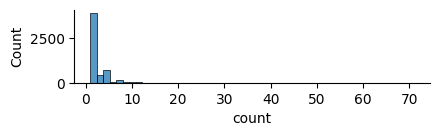

In [8]:
sns.displot(
    data=best_reads.value_counts(subset=['base_id']).reset_index(),
    x='count', bins=50, aspect=3.0, height=1.5
)

### filter ambiguous hits

We remove reads that mapped in more than one region, regardless of whether it was the same species or not.

In [9]:
unambiguous = best_reads.value_counts(subset=['base_id']).reset_index().query('count < 2')
unambiguous

,base_id,count
2844,1116:13159:7169,1
2845,2207:24180:18564,1
2846,2206:15473:4180,1
2847,2207:7740:12058,1
2848,1102:9536:20199,1
...,...,...
5308,1128:25317:40614,1
5309,2117:12023:48069,1
5310,2117:12286:28411,1
5311,2117:12926:9895,1


In [10]:
top_reads = best_reads[best_reads.base_id.isin(unambiguous.base_id)].copy()
top_reads

,read,ref,identity,length,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id
263,J00148:56:HM5WHBBXX:1:1101:13423:2246,ref|NZ_MSPX01000036.1|,100.0,126,0,0,1,126,904,1029,1.070000e-59,233.0,126,100,forward,1101:13423:2246
8194,J00148:56:HM5WHBBXX:1:1101:17452:9614,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,8702,8852,1.680000e-73,279.0,151,100,forward,1101:17452:9614
9715,J00148:56:HM5WHBBXX:1:1101:2777:11618,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,8694,8844,1.680000e-73,279.0,151,100,forward,1101:2777:11618
12740,J00148:56:HM5WHBBXX:1:1101:20669:21518,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,919,1069,1.680000e-73,279.0,151,100,forward,1101:20669:21518
14741,J00148:56:HM5WHBBXX:1:1101:6411:25439,ref|NZ_MSPX01000036.1|,100.0,144,0,0,8,151,3014,3157,1.300000e-69,267.0,151,95,forward,1101:6411:25439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6986378,J00148:56:HM5WHBBXX:2:2228:21318:10475,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,3934,4084,1.680000e-73,279.0,151,100,forward,2228:21318:10475
6987016,J00148:56:HM5WHBBXX:2:2228:5842:13799,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,3881,4031,1.680000e-73,279.0,151,100,forward,2228:5842:13799
6991206,J00148:56:HM5WHBBXX:2:2228:28980:20093,ref|NZ_MSPX01000036.1|,100.0,151,0,0,1,151,3959,4109,1.680000e-73,279.0,151,100,forward,2228:28980:20093
6992555,J00148:56:HM5WHBBXX:2:2228:22567:25509,ref|NZ_MSPX01000036.1|,100.0,141,0,0,1,141,893,1033,5.580000e-68,261.0,141,100,forward,2228:22567:25509


## Merge with taxonomic reference

In [11]:
top_reads['ref'] = top_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))

In [12]:
top_reads

,read,ref,identity,length,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id
263,J00148:56:HM5WHBBXX:1:1101:13423:2246,NZ_MSPX01000036.1,100.0,126,0,0,1,126,904,1029,1.070000e-59,233.0,126,100,forward,1101:13423:2246
8194,J00148:56:HM5WHBBXX:1:1101:17452:9614,NZ_MSPX01000036.1,100.0,151,0,0,1,151,8702,8852,1.680000e-73,279.0,151,100,forward,1101:17452:9614
9715,J00148:56:HM5WHBBXX:1:1101:2777:11618,NZ_MSPX01000036.1,100.0,151,0,0,1,151,8694,8844,1.680000e-73,279.0,151,100,forward,1101:2777:11618
12740,J00148:56:HM5WHBBXX:1:1101:20669:21518,NZ_MSPX01000036.1,100.0,151,0,0,1,151,919,1069,1.680000e-73,279.0,151,100,forward,1101:20669:21518
14741,J00148:56:HM5WHBBXX:1:1101:6411:25439,NZ_MSPX01000036.1,100.0,144,0,0,8,151,3014,3157,1.300000e-69,267.0,151,95,forward,1101:6411:25439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6986378,J00148:56:HM5WHBBXX:2:2228:21318:10475,NZ_MSPX01000036.1,100.0,151,0,0,1,151,3934,4084,1.680000e-73,279.0,151,100,forward,2228:21318:10475
6987016,J00148:56:HM5WHBBXX:2:2228:5842:13799,NZ_MSPX01000036.1,100.0,151,0,0,1,151,3881,4031,1.680000e-73,279.0,151,100,forward,2228:5842:13799
6991206,J00148:56:HM5WHBBXX:2:2228:28980:20093,NZ_MSPX01000036.1,100.0,151,0,0,1,151,3959,4109,1.680000e-73,279.0,151,100,forward,2228:28980:20093
6992555,J00148:56:HM5WHBBXX:2:2228:22567:25509,NZ_MSPX01000036.1,100.0,141,0,0,1,141,893,1033,5.580000e-68,261.0,141,100,forward,2228:22567:25509


In [13]:
reference = pd.read_json("../results/2025-03-24-marcos-db/marcos21.reference.json").rename(columns={"sequence_id": "ref"})

In [14]:
reference

,accession,ref,taxid,organism,length
0,GCF_000743885.1,NZ_JOJU01000001.1,178901,Acetobacter malorum,3513430
1,GCF_000743885.1,NZ_JOJU01000002.1,178901,Acetobacter malorum,3513430
2,GCF_000743885.1,NZ_JOJU01000003.1,178901,Acetobacter malorum,3513430
3,GCF_000743885.1,NZ_JOJU01000004.1,178901,Acetobacter malorum,3513430
4,GCF_000743885.1,NZ_JOJU01000005.1,178901,Acetobacter malorum,3513430
...,...,...,...,...,...
17773,GCF_001421705.1,NZ_LMKO01000024.1,1735686,Xylophilus sp. Leaf220,4483623
17774,GCF_001421705.1,NZ_LMKO01000025.1,1735686,Xylophilus sp. Leaf220,4483623
17775,GCF_001421705.1,NZ_LMKO01000026.1,1735686,Xylophilus sp. Leaf220,4483623
17776,GCF_001421705.1,NZ_LMKO01000027.1,1735686,Xylophilus sp. Leaf220,4483623


In [15]:
hits = pd.merge(top_reads, reference, on='ref', how='left')
hits = hits.value_counts(subset=['taxid', 'organism']).reset_index()

In [16]:
hits

,taxid,organism,count
0,1672749,Xaviernesmea rhizosphaerae,1462
1,1197720,Microbacterium barkeri 2011-R4,454
2,1736266,Duganella sp. Leaf126,300
3,1736303,Arthrobacter sp. Leaf234,80
4,1522176,Frigoribacterium endophyticum,29
5,1219054,Sphingomonas sanguinis NBRC 13937,24
6,1850094,Sinorhizobium shofinae,24
7,885042,Williamsia phyllosphaerae,17
8,1749036,Dyadobacter endophyticus,10
9,243924,Pseudomonas lutea,9


## Comparing with Marco

In [17]:
import taxoniq

In [18]:
def taxid(x):
    try:
        return taxoniq.Taxon(scientific_name=x).tax_id
    except KeyError:
        return pd.NA

In [19]:
marcos_results = pd.read_csv("../data/marco.pv064.species_counts.csv", sep="\t")
marcos_results['taxid'] = marcos_results['OTU'].apply(taxid)

In [20]:
marcos_results

,OTU,lib,taxon,site,habitat,count,taxid
0,Arthrobacter sp. Leaf234,PV064,Artemisia_herba_alba,E1,waste,94,1736303
1,Aureimonas sp. Leaf324,PV064,Artemisia_herba_alba,E1,waste,16,1736336
2,Caulobacter zeae,PV064,Artemisia_herba_alba,E1,waste,2,2055137
3,Cellulomonas sp. Leaf334,PV064,Artemisia_herba_alba,E1,waste,4,1736339
4,Cupriavidus gilardii,PV064,Artemisia_herba_alba,E1,waste,28,82541
5,Duganella sp. Leaf126,PV064,Artemisia_herba_alba,E1,waste,1494,1736266
6,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774,1749036
7,Ensifer shofinae,PV064,Artemisia_herba_alba,E1,waste,576,<NA>
8,Epibacterium ulvae,PV064,Artemisia_herba_alba,E1,waste,2,1156985
9,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6,1522176


In [21]:
pd.merge(marcos_results, hits, on='taxid', how='inner')

,OTU,lib,taxon,site,habitat,count_x,taxid,organism,count_y
0,Arthrobacter sp. Leaf234,PV064,Artemisia_herba_alba,E1,waste,94,1736303,Arthrobacter sp. Leaf234,80
1,Cellulomonas sp. Leaf334,PV064,Artemisia_herba_alba,E1,waste,4,1736339,Cellulomonas sp. Leaf334,1
2,Duganella sp. Leaf126,PV064,Artemisia_herba_alba,E1,waste,1494,1736266,Duganella sp. Leaf126,300
3,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774,1749036,Dyadobacter endophyticus,10
4,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6,1522176,Frigoribacterium endophyticum,29
5,Geodermatophilus sp. Leaf369,PV064,Artemisia_herba_alba,E1,waste,2,1736354,Geodermatophilus sp. Leaf369,1
6,Microbacterium barkeri 2011-R4,PV064,Artemisia_herba_alba,E1,waste,4248,1197720,Microbacterium barkeri 2011-R4,454
7,Modestobacter roseus,PV064,Artemisia_herba_alba,E1,waste,2,1181884,Modestobacter roseus,2
8,Pseudomonas lutea,PV064,Artemisia_herba_alba,E1,waste,6,243924,Pseudomonas lutea,9
9,Sphingomonas sanguinis NBRC 13937,PV064,Artemisia_herba_alba,E1,waste,6,1219054,Sphingomonas sanguinis NBRC 13937,24


## Attempt 2

In [22]:
best_reads = all_read.query('length > 125 and identity == 100.0').copy()
best_reads['base_id'] = best_reads['read'].apply(lambda x: x.replace("J00148:56:HM5WHBBXX:1:", "").replace("J00148:56:HM5WHBBXX:2:", ""))
best_reads['ssstart'] = best_reads.apply(lambda x: min(x.sstart, x.send), axis=1)
best_reads['ssend'] = best_reads.apply(lambda x: max(x.sstart, x.send), axis=1)
paired_reads = best_reads.groupby(['base_id', 'ref', 'ssstart', 'ssend'], as_index=False)['file'].nunique()
paired_reads = paired_reads[paired_reads.file == 2]
paired_reads

,base_id,ref,ssstart,ssend,file
0,1101:10125:45836,ref|NZ_AKVP01000087.1|,883,1023,2
1,1101:10125:45836,ref|NZ_BMIA01000020.1|,202,342,2
2,1101:10125:45836,ref|NZ_MSPX01000036.1|,3331,3471,2
3,1101:10186:4409,ref|NZ_MSPX01000036.1|,8701,8835,2
27,1101:12642:4901,ref|NZ_AKVP01000087.1|,1200,1330,2
...,...,...,...,...,...
20962,2228:30502:12251,ref|NZ_AKVP01000085.1|,1479,1612,2
20963,2228:30502:12251,ref|NZ_MSPX01000036.1|,8240,8373,2
20965,2228:30817:43708,ref|NZ_AKVP01000087.1|,1191,1318,2
20966,2228:30817:43708,ref|NZ_MSPX01000036.1|,3036,3163,2


In [23]:
best_reads = best_reads[best_reads['base_id'].isin(paired_reads['base_id'])].query('file == "forward"')
unambiguous = best_reads.value_counts(subset=['base_id']).reset_index().query('count < 2')
top_reads = best_reads[best_reads.base_id.isin(unambiguous.base_id)].copy()
top_reads['ref'] = top_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
hits = pd.merge(top_reads, reference, on='ref', how='left')
hits = hits.value_counts(subset=['taxid', 'organism']).reset_index()
pd.merge(marcos_results, hits, on='taxid', how='inner', suffixes=['_marcos', '_bruno'])[['OTU', 'organism', 'taxid', 'count_marcos', 'count_bruno']]

,OTU,organism,taxid,count_marcos,count_bruno
0,Arthrobacter sp. Leaf234,Arthrobacter sp. Leaf234,1736303,94,20
1,Duganella sp. Leaf126,Duganella sp. Leaf126,1736266,1494,38
2,Dyadobacter endophyticus,Dyadobacter endophyticus,1749036,774,3
3,Frigoribacterium endophyticum,Frigoribacterium endophyticum,1522176,6,10
4,Geodermatophilus sp. Leaf369,Geodermatophilus sp. Leaf369,1736354,2,1
5,Microbacterium barkeri 2011-R4,Microbacterium barkeri 2011-R4,1197720,4248,69
6,Modestobacter roseus,Modestobacter roseus,1181884,2,1
7,Pseudomonas lutea,Pseudomonas lutea,243924,6,2
8,Sphingomonas sanguinis NBRC 13937,Sphingomonas sanguinis NBRC 13937,1219054,6,10


## Attempt 3

In [ ]:
best_reads = all_read.query('length > 125 and identity == 100.0').copy()
best_reads['base_id'] = best_reads['read'].apply(lambda x: x.replace("J00148:56:HM5WHBBXX:1:", "").replace("J00148:56:HM5WHBBXX:2:", ""))
best_reads['ssstart'] = best_reads.apply(lambda x: min(x.sstart, x.send), axis=1)
best_reads['ssend'] = best_reads.apply(lambda x: max(x.sstart, x.send), axis=1)
paired_reads = best_reads.groupby(['base_id', 'ref', 'ssstart', 'ssend'], as_index=False)['file'].nunique()
paired_reads = paired_reads[paired_reads.file == 2]
paired_reads

KeyError: 'ssstart'

In [ ]:
best_reads = best_reads[best_reads['base_id'].isin(paired_reads['base_id'])].query('file == "forward"')
unambiguous = best_reads.value_counts(subset=['base_id', 'ref']).reset_index().value_counts(subset=['base_id']).reset_index().query('count < 2')
top_reads = best_reads[best_reads.base_id.isin(unambiguous.base_id)].copy()
top_reads['ref'] = top_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
hits = pd.merge(top_reads, reference, on='ref', how='left')
hits = hits.value_counts(subset=['taxid', 'organism']).reset_index()
pd.merge(marcos_results, hits, on='taxid', how='inner', suffixes=['_marcos', '_bruno'])[['OTU', 'organism', 'taxid', 'count_marcos', 'count_bruno']]

,OTU,organism,taxid,count_marcos,count_bruno
0,Arthrobacter sp. Leaf234,Arthrobacter sp. Leaf234,1736303,94,20
1,Duganella sp. Leaf126,Duganella sp. Leaf126,1736266,1494,38
2,Dyadobacter endophyticus,Dyadobacter endophyticus,1749036,774,3
3,Frigoribacterium endophyticum,Frigoribacterium endophyticum,1522176,6,10
4,Geodermatophilus sp. Leaf369,Geodermatophilus sp. Leaf369,1736354,2,1
5,Microbacterium barkeri 2011-R4,Microbacterium barkeri 2011-R4,1197720,4248,69
6,Modestobacter roseus,Modestobacter roseus,1181884,2,1
7,Pseudomonas lutea,Pseudomonas lutea,243924,6,2
8,Rathayibacter tritici,Rathayibacter tritici,33888,2,2
9,Sphingomonas panacis,Sphingomonas panacis,1560345,2,3


## Attempt 4

In [62]:
best_reads = all_read.query('length > 125 and qcovs == 100.0').copy()
best_reads['ref'] = best_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
pd.merge(best_reads, reference, on='ref', how='left').query('taxid == 1736266')

,read,ref,identity,length_x,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,accession,taxid,organism,length_y
3,J00148:56:HM5WHBBXX:1:1101:3336:3512,NZ_LMNW01000030.1,98.675,151,2,0,1,151,60,210,3.630000e-70,268.0,151,100,forward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
117,J00148:56:HM5WHBBXX:1:1101:24667:5622,NZ_LMNW01000030.1,98.496,133,2,0,1,133,360,492,3.170000e-60,235.0,133,100,forward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
147,J00148:56:HM5WHBBXX:1:1101:6898:7539,NZ_LMNW01000030.1,96.324,136,5,0,1,136,210,345,7.060000e-57,224.0,136,100,forward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
392,J00148:56:HM5WHBBXX:1:1101:13149:15029,NZ_LMNW01000030.1,98.675,151,2,0,1,151,741,891,3.630000e-70,268.0,151,100,forward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
482,J00148:56:HM5WHBBXX:1:1101:4868:17561,NZ_LMNW01000030.1,99.225,129,1,0,1,129,787,915,1.100000e-59,233.0,129,100,forward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400465,J00148:56:HM5WHBBXX:2:2228:7476:36042,NZ_LMNW01000030.1,98.675,151,1,1,1,151,556,407,1.300000e-69,267.0,151,100,backward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
1400942,J00148:56:HM5WHBBXX:2:2228:27458:43761,NZ_LMNW01000030.1,96.026,151,6,0,1,151,835,685,1.700000e-63,246.0,151,100,backward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
1401023,J00148:56:HM5WHBBXX:2:2228:3112:46170,NZ_LMNW01000030.1,97.351,151,4,0,1,151,271,121,7.850000e-67,257.0,151,100,backward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
1401027,J00148:56:HM5WHBBXX:2:2228:4594:46592,NZ_LMNW01000030.1,99.338,151,1,0,1,151,665,515,7.800000e-72,274.0,151,100,backward,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014


In [63]:
best_reads['base_id'] = best_reads['read'].apply(lambda x: x.replace("J00148:56:HM5WHBBXX:1:", "").replace("J00148:56:HM5WHBBXX:2:", ""))
paired_reads = best_reads.groupby(['base_id', 'ref'], as_index=False)['file'].nunique()
paired_reads = paired_reads[paired_reads.file == 2]
paired_reads['ref'] = paired_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
pd.merge(paired_reads, reference, on='ref', how='left').query('taxid == 1736266')


,base_id,ref,file,accession,taxid,organism,length
249,1101:10277:48139,NZ_LMNW01000032.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
372,1101:10460:16102,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
375,1101:10470:18335,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
380,1101:10927:47542,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
400,1101:11140:26424,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
...,...,...,...,...,...,...,...
145612,2228:6563:37941,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
145735,2228:7141:33879,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
145815,2228:7902:25070,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
145819,2228:8166:35268,NZ_LMNW01000030.1,2,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014


In [ ]:
best_reads = best_reads[best_reads['base_id'].isin(paired_reads['base_id'])].query('file == "forward"')
best_reads['ref'] = best_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
pd.merge(best_reads, reference, on='ref', how='left').query('taxid == 1736266')



,read,ref,identity,length_x,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id,accession,taxid,organism,length_y
3,J00148:56:HM5WHBBXX:1:1101:3336:3512,NZ_LMNW01000030.1,98.675,151,2,0,1,151,60,210,3.630000e-70,268.0,151,100,forward,1101:3336:3512,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
91,J00148:56:HM5WHBBXX:1:1101:24667:5622,NZ_LMNW01000030.1,98.496,133,2,0,1,133,360,492,3.170000e-60,235.0,133,100,forward,1101:24667:5622,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
120,J00148:56:HM5WHBBXX:1:1101:6898:7539,NZ_LMNW01000030.1,96.324,136,5,0,1,136,210,345,7.060000e-57,224.0,136,100,forward,1101:6898:7539,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
294,J00148:56:HM5WHBBXX:1:1101:13149:15029,NZ_LMNW01000030.1,98.675,151,2,0,1,151,741,891,3.630000e-70,268.0,151,100,forward,1101:13149:15029,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
381,J00148:56:HM5WHBBXX:1:1101:4868:17561,NZ_LMNW01000030.1,99.225,129,1,0,1,129,787,915,1.100000e-59,233.0,129,100,forward,1101:4868:17561,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496050,J00148:56:HM5WHBBXX:2:2228:12114:31980,NZ_LMNW01000030.1,99.338,151,1,0,1,151,27,177,7.800000e-72,274.0,151,100,forward,2228:12114:31980,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
496296,J00148:56:HM5WHBBXX:2:2228:7141:33879,NZ_LMNW01000030.1,100.000,151,0,0,1,151,9,159,1.680000e-73,279.0,151,100,forward,2228:7141:33879,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
496384,J00148:56:HM5WHBBXX:2:2228:27458:43761,NZ_LMNW01000030.1,96.689,151,5,0,1,151,641,791,3.650000e-65,252.0,151,100,forward,2228:27458:43761,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
496608,J00148:56:HM5WHBBXX:2:2228:28351:44394,NZ_LMNW01000032.1,87.417,151,19,0,1,151,283246,283396,8.130000e-42,174.0,151,100,forward,2228:28351:44394,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014


In [72]:
best_reads.query('base_id == "1101:15940:32631"')

,read,ref,identity,length,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id
3622186,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_MSPX01000036.1,100.000,151,0,0,1,151,3889,4039,1.680000e-73,279.0,151,100,forward,1101:15940:32631
3622187,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_LMNW01000030.1,99.338,151,1,0,1,151,536,686,7.800000e-72,274.0,151,100,forward,1101:15940:32631
3622188,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_AKVP01000087.1,98.675,151,2,0,1,151,465,315,3.630000e-70,268.0,151,100,forward,1101:15940:32631
3622189,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_LVXY01000028.1,92.715,151,11,0,1,151,464,314,3.710000e-55,219.0,151,100,forward,1101:15940:32631


In [73]:
pd.merge(best_reads, reference, on='ref', how='left').query('base_id == "1101:15940:32631"')

,read,ref,identity,length_x,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id,accession,taxid,organism,length_y
261540,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_MSPX01000036.1,100.000,151,0,0,1,151,3889,4039,1.680000e-73,279.0,151,100,forward,1101:15940:32631,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
261541,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_LMNW01000030.1,99.338,151,1,0,1,151,536,686,7.800000e-72,274.0,151,100,forward,1101:15940:32631,GCF_001423125.1,1736266,Duganella sp. Leaf126,5315014
261542,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_AKVP01000087.1,98.675,151,2,0,1,151,465,315,3.630000e-70,268.0,151,100,forward,1101:15940:32631,GCF_000299315.2,1197720,Microbacterium barkeri 2011-R4,3627873
261543,J00148:56:HM5WHBBXX:2:1101:15940:32631,NZ_LVXY01000028.1,92.715,151,11,0,1,151,464,314,3.710000e-55,219.0,151,100,forward,1101:15940:32631,GCF_001658125.1,82541,Cupriavidus gilardii,5559922


In [67]:
best_reads.value_counts(subset=['base_id']).reset_index().query('base_id == "1101:4868:17561"')

,base_id,count
8122,1101:4868:17561,3


,base_id,count
19450,1119:16072:34196,1
19451,1118:14478:48280,1
19452,1123:11972:43058,1
19453,2213:30360:30116,1
19454,1122:10815:29378,1
...,...,...
25899,1208:8075:10176,1
25900,2201:13768:9104,1
25901,1208:8633:18353,1
25902,1208:8988:5605,1


In [ ]:

# unambiguous = best_reads.value_counts(subset=['base_id', 'ref']).reset_index().value_counts(subset=['base_id']).reset_index().query('count < 2')

best_reads['ref'] = best_reads['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
top_reads = pd.merge(best_reads, reference, on='ref', how='left')# .query('taxid == 1736266')
# unambiguous = top_reads.value_counts(subset=['base_id', 'taxid']).reset_index().value_counts(subset=['base_id']).reset_index().query('count < 2')
unambiguous = top_reads.value_counts(subset=['base_id', 'taxid']).reset_index().value_counts(subset=['base_id']).reset_index().query('count < 2')
top_reads = top_reads[top_reads.base_id.isin(unambiguous.base_id)].copy()
top_reads

,read,ref,identity,length_x,mismatch,gap,qstart,qend,sstart,send,evalue,bitscore,qlen,qcovs,file,base_id,accession,taxid,organism,length_y
88,J00148:56:HM5WHBBXX:1:1101:4807:5534,NZ_MSPX01000036.1,91.096,146,13,0,1,146,1643,1788,4.630000e-49,198.0,146,100,forward,1101:4807:5534,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
89,J00148:56:HM5WHBBXX:1:1101:17543:5622,NZ_AKVP01000102.1,92.053,151,12,0,1,151,631,481,1.720000e-53,213.0,151,100,forward,1101:17543:5622,GCF_000299315.2,1197720,Microbacterium barkeri 2011-R4,3627873
118,J00148:56:HM5WHBBXX:1:1101:24525:6783,NZ_MSPX01000036.1,94.702,151,8,0,1,151,424,574,3.680000e-60,235.0,151,100,forward,1101:24525:6783,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
119,J00148:56:HM5WHBBXX:1:1101:27062:7134,NZ_MSPX01000036.1,79.699,133,24,3,1,131,7838,7969,1.980000e-17,93.5,131,100,forward,1101:27062:7134,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
281,J00148:56:HM5WHBBXX:1:1101:17452:9614,NZ_MSPX01000036.1,100.000,151,0,0,1,151,8702,8852,1.680000e-73,279.0,151,100,forward,1101:17452:9614,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496351,J00148:56:HM5WHBBXX:2:2228:21369:38732,NZ_MSPX01000036.1,96.026,151,5,1,1,151,1378,1527,6.110000e-63,244.0,151,100,forward,2228:21369:38732,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
496352,J00148:56:HM5WHBBXX:2:2228:29041:39576,NZ_MSPX01000036.1,80.420,143,25,3,1,141,7836,7977,2.770000e-21,106.0,141,100,forward,2228:29041:39576,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
496355,J00148:56:HM5WHBBXX:2:2228:3011:40543,NZ_MSPX01000036.1,80.137,146,26,3,1,144,7836,7980,2.840000e-21,106.0,144,100,forward,2228:3011:40543,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
497142,J00148:56:HM5WHBBXX:2:2228:28483:45818,NZ_MSPX01000036.1,92.763,152,10,1,1,151,7943,8094,3.710000e-55,219.0,151,100,forward,2228:28483:45818,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744


In [91]:
# hits = pd.merge(top_reads, reference, on='ref', how='left')
hits = top_reads.value_counts(subset=['taxid', 'organism']).reset_index()
pd.merge(marcos_results, hits, on='taxid', how='inner', suffixes=['_marcos', '_bruno'])[['OTU', 'organism', 'taxid', 'count_marcos', 'count_bruno']]



,OTU,organism,taxid,count_marcos,count_bruno
0,Arthrobacter sp. Leaf234,Arthrobacter sp. Leaf234,1736303,94,112
1,Aureimonas sp. Leaf324,Aureimonas sp. Leaf324,1736336,16,14
2,Caulobacter zeae,Caulobacter zeae,2055137,2,3
3,Cellulomonas sp. Leaf334,Cellulomonas sp. Leaf334,1736339,4,4
4,Cupriavidus gilardii,Cupriavidus gilardii,82541,28,309
5,Duganella sp. Leaf126,Duganella sp. Leaf126,1736266,1494,187
6,Dyadobacter endophyticus,Dyadobacter endophyticus,1749036,774,44
7,Epibacterium ulvae,Epibacterium ulvae,1156985,2,5
8,Frigoribacterium endophyticum,Frigoribacterium endophyticum,1522176,6,11
9,Geodermatophilus sp. Leaf369,Geodermatophilus sp. Leaf369,1736354,2,1


## Attempt 5

In [ ]:
all_read['base_id'] = all_read['read'].apply(lambda x: x.replace("J00148:56:HM5WHBBXX:1:", "").replace("J00148:56:HM5WHBBXX:2:", ""))
# C1 : length > 125 and query coverage == 100
all_read['C1'] = all_read.apply(lambda x: x['length'] > 125 and x['qcovs'] == 100.0, axis=1)

In [107]:
# C2 : only unique matches
unambiguous = all_read.value_counts(subset=['base_id', 'ref']).reset_index().value_counts(subset=['base_id']).reset_index().query('count < 2')
all_read['C2'] = all_read['base_id'].isin(unambiguous.base_id)

In [118]:
paired_reads = all_read.groupby(['base_id', 'ref'], as_index=False)['file'].nunique()
paired_reads = paired_reads[paired_reads.file == 2]
all_read['C3'] = all_read['base_id'].isin(paired_reads.base_id)


In [130]:
#
all_read['ref'] = all_read['ref'].apply(lambda x: x.replace("ref|", "").replace("|", ""))
top_reads = pd.merge(all_read.query('C1 == True and C2 == True and C3 == True'), reference, on='ref', how='left')#.query('taxid == 1736266')
top_reads


,read,ref,identity,length_x,mismatch,gap,qstart,qend,sstart,send,...,file,base_id,C1,C2,C4,C3,accession,taxid,organism,length_y
0,J00148:56:HM5WHBBXX:1:1101:4807:5534,NZ_MSPX01000036.1,91.096,146,13,0,1,146,1643,1788,...,forward,1101:4807:5534,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
1,J00148:56:HM5WHBBXX:1:1101:27062:7134,NZ_MSPX01000036.1,79.699,133,24,3,1,131,7838,7969,...,forward,1101:27062:7134,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
2,J00148:56:HM5WHBBXX:1:1101:28442:14625,NZ_MSPX01000036.1,82.000,150,26,1,1,149,7836,7985,...,forward,1101:28442:14625,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
3,J00148:56:HM5WHBBXX:1:1101:4543:15311,NZ_LVXY01000024.1,88.028,142,13,4,1,142,2032,1895,...,forward,1101:4543:15311,True,True,False,True,GCF_001658125.1,82541,Cupriavidus gilardii,5559922
4,J00148:56:HM5WHBBXX:1:1101:20527:27496,NZ_MSPX01000036.1,81.457,151,25,3,1,149,7832,7981,...,forward,1101:20527:27496,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5159,J00148:56:HM5WHBBXX:2:2228:14001:26775,NZ_MSPX01000036.1,80.690,145,25,3,1,143,7979,7836,...,backward,2228:14001:26775,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
5160,J00148:56:HM5WHBBXX:2:2228:15290:32666,NZ_AKVP01000090.1,95.364,151,7,0,1,151,984,1134,...,backward,2228:15290:32666,True,True,False,True,GCF_000299315.2,1197720,Microbacterium barkeri 2011-R4,3627873
5161,J00148:56:HM5WHBBXX:2:2228:29041:39576,NZ_MSPX01000036.1,80.420,143,25,3,1,141,7977,7836,...,backward,2228:29041:39576,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744
5162,J00148:56:HM5WHBBXX:2:2228:3011:40543,NZ_MSPX01000036.1,80.137,146,26,3,1,144,7980,7836,...,backward,2228:3011:40543,True,True,False,True,GCF_002078095.1,1672749,Xaviernesmea rhizosphaerae,5181744


In [131]:

# hits = pd.merge(top_reads, reference, on='ref', how='left')
hits = top_reads.value_counts(subset=['taxid', 'organism']).reset_index()
pd.merge(marcos_results, hits, on='taxid', how='inner', suffixes=['_marcos', '_bruno'])[['OTU', 'organism', 'taxid', 'count_marcos', 'count_bruno']]

,OTU,organism,taxid,count_marcos,count_bruno
0,Arthrobacter sp. Leaf234,Arthrobacter sp. Leaf234,1736303,94,47
1,Cellulomonas sp. Leaf334,Cellulomonas sp. Leaf334,1736339,4,2
2,Cupriavidus gilardii,Cupriavidus gilardii,82541,28,242
3,Duganella sp. Leaf126,Duganella sp. Leaf126,1736266,1494,222
4,Dyadobacter endophyticus,Dyadobacter endophyticus,1749036,774,97
5,Frigoribacterium endophyticum,Frigoribacterium endophyticum,1522176,6,2
6,Mesoplasma seiffertii ATCC 49495,Mesoplasma seiffertii ATCC 49495,1336238,2,2
7,Microbacterium barkeri 2011-R4,Microbacterium barkeri 2011-R4,1197720,4248,73
8,Modestobacter roseus,Modestobacter roseus,1181884,2,2
9,Mucilaginibacter polytrichastri,Mucilaginibacter polytrichastri,1302689,4,4


In [132]:
hits

,taxid,organism,count
0,1672749,Xaviernesmea rhizosphaerae,2363
1,885042,Williamsia phyllosphaerae,1397
2,1154758,Pseudomonas avellanae BPIC 631,342
3,82541,Cupriavidus gilardii,242
4,1736266,Duganella sp. Leaf126,222
5,280332,Bradyrhizobium jicamae,166
6,1749036,Dyadobacter endophyticus,97
7,1197720,Microbacterium barkeri 2011-R4,73
8,1636152,Planctomyces sp. SH-PL62,60
9,1736303,Arthrobacter sp. Leaf234,47
